# Лабораторная работа №1. Разведочный анализ данных.
## Исследование и визуализация данных на примере HousingData (Бостон).

В качестве набора данных мы будем использовать HousingData. Это классический набор данных для анализа недвижимости.

**Задача:** Исследование факторов, влияющих на стоимость жилья.

**Состав данных:**
- crim: Уровень преступности
- zn: Доля жилых земель (застройка > 25,000 кв.футов)
- indus: Доля акров, занятых под бизнес
- chas: Фиктивная переменная реки Чарльз (= 1, если ограничивает реку)
- nox: Концентрация оксидов азота
- rm: Среднее количество комнат в жилом помещении
- age: Доля построек до 1940 года
- dis: Взвешенные расстояния до центров занятости Бостона
- rad: Индекс доступности к радиальным магистралям
- tax: Полная ставка налога на имущество
- ptratio: Соотношение учеников и учителей по городам
- b: Доля лиц афроамериканского происхождения
- lstat: Процент населения с более низким статусом
- medv: Целевой признак — медианная стоимость домов в $1000

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
data = pd.read_csv('HousingData.csv')

print('Данные успешно загружены!')

Данные успешно загружены!


In [2]:
print('Первые 5 строк датасета:')
display(data.head())

print('\nРазмер датасета:')
print(data.shape)

print('\nТипы данных и пропуски:')
print(data.info())

print('\nОсновные статистические характеристики:')
display(data.describe())

Первые 5 строк датасета:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2



Размер датасета:
(506, 14)

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None

Основные статистические характеристики:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Визуальное исследование данных

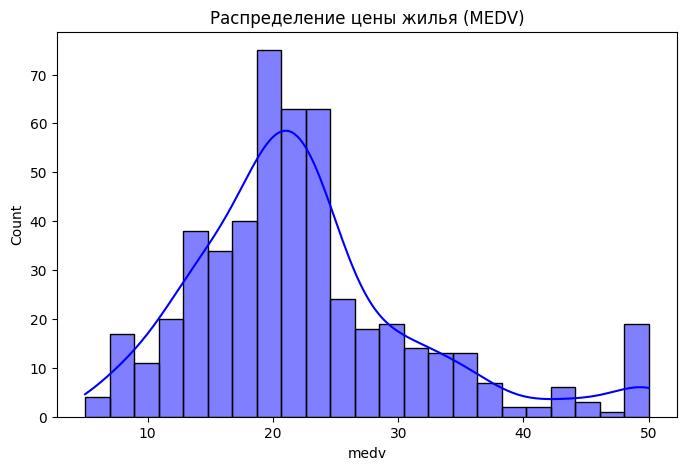

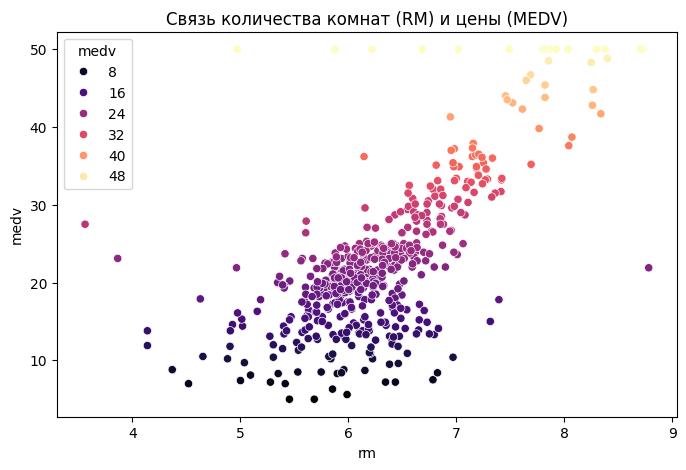

In [3]:
# Распределение целевого признака
plt.figure(figsize=(8,5))
sns.histplot(data['medv'], kde=True, color='blue')
plt.title('Распределение цены жилья (MEDV)')
plt.show()

# Диаграмма рассеяния как в примере
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='rm', y='medv', hue='medv', palette='magma')
plt.title('Связь количества комнат (RM) и цены (MEDV)')
plt.show()

### Корреляционный анализ

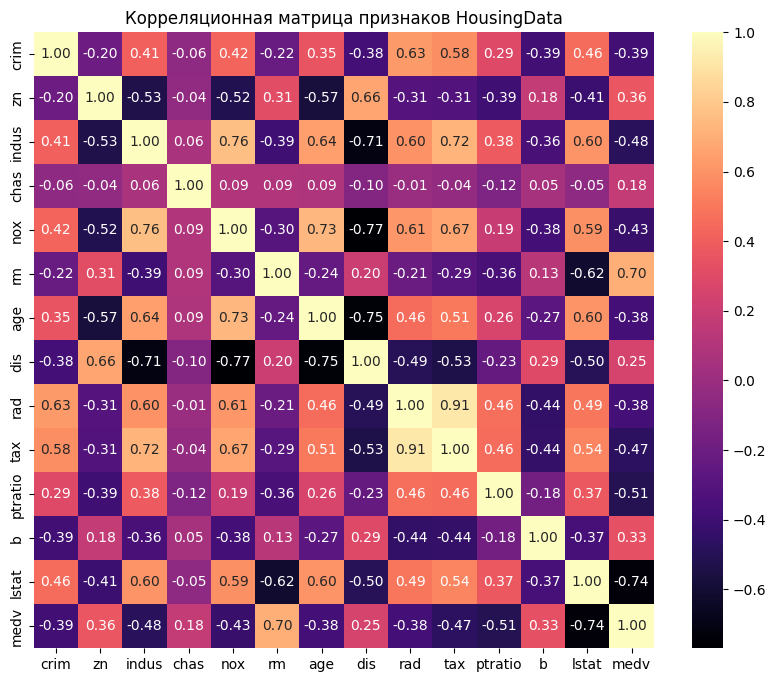

In [4]:
corr_matrix = data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='magma')
plt.title('Корреляционная матрица признаков HousingData')
plt.show()

**Выводы из корреляции:**

1. Количество комнат (RM) имеет сильную прямую связь с ценой.
2. Социальный статус (LSTAT) имеет сильную обратную связь с ценой.